In [42]:
from matplotlib import pyplot as plt
import matplotlib as mpl

plt.style.use('default')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['text.usetex'] = True
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.size'] = 15

### Expected Improvement in a Noise Setting

Assume that the goal of optimization is *minimization* of the objective function. Consider the Expected Improvement (EI) for the setting without noise in the objective function:

$$\mathrm{EI}(x) = \sigma(x) \varphi\left(\frac{\Delta(x)}{\sigma(x)}\right) + \Delta\Phi\left(\frac{\Delta(x)}{\sigma(x)}\right),$$
where
- $\mu(x)$ is the posterior mean at $x$
- $\sigma(x)$ is the posterior standard deviation at $x$
- $\varphi$ is the density of the standard normal distribution (i.e., normal distribution with mean 0 and variance 1)
- $\Phi$ is the cdf of the standard normal distribution
- $\Delta(x) \coloneqq f^* - \mu(x)$ where $f^*$ is the smallest value observed so far

Its extension to the setting with noise (EIn) is given by:

$$\mathrm{EIn}(x) = \sigma_{\text{total}}^2(x) \varphi\left(\frac{\Delta^*(x)}{\sigma_{\text{total}}^2(x)}\right) + \Delta^*\Phi\left(\frac{\Delta^*(x)}{\sigma_{\text{total}}^2(x)}\right),$$
where
- $\Delta^*(x) \coloneqq f^*_\text{effective} - \mu(x)$
- $\sigma_{\text{total}}^2(x) \coloneqq \sigma_{\text{GP}}^2 + \sigma_{\text{N}}^2$, see slide 14 from 04/12/2024

#### Task 1
Implement the formulas for EI and EIn. Compare the results.


In [22]:
import numpy as np
from scipy.stats import norm


def EI(mu:float, sigma:float, f_star:float):
    if sigma <= 0:
        return 0
    delta =  f_star - mu
    z = delta / sigma
    return sigma*norm.pdf(z) + delta*norm.cdf(z)
    

def EIn(mu:float, sigma_GP:float, sigma_N:float, f_star_effective:float):
    if sigma_GP <= 0:
        return 0
    delta_star =  f_star_effective - mu
    sigma_total_2 = sigma_GP**2 + sigma_N**2
    z = delta_star / sigma_total_2
    return sigma_total_2*norm.pdf(z) + delta_star*norm.cdf(z)

    
print(EI(1,np.sqrt(1e-100),0))
print(EI(2,1,0))
print(EI(0,np.sqrt(2),2))
print(EI(0,np.sqrt(10),2))

print(EIn(1,np.sqrt(1e-100),0,0))
print(EIn(2,1,0,0))
print(EIn(0,np.sqrt(2),1,2))
print(EIn(0,np.sqrt(10),0.5, 2))



0.0
0.00849070261682966
2.050254541660012
2.5057938380690183
0.0
0.00849070261682966
2.453358941473211
5.166754735677543


### Gaussian Process Regression with noise

#### Task 2

Exteing the following code to support noisy outputs from the objective function.

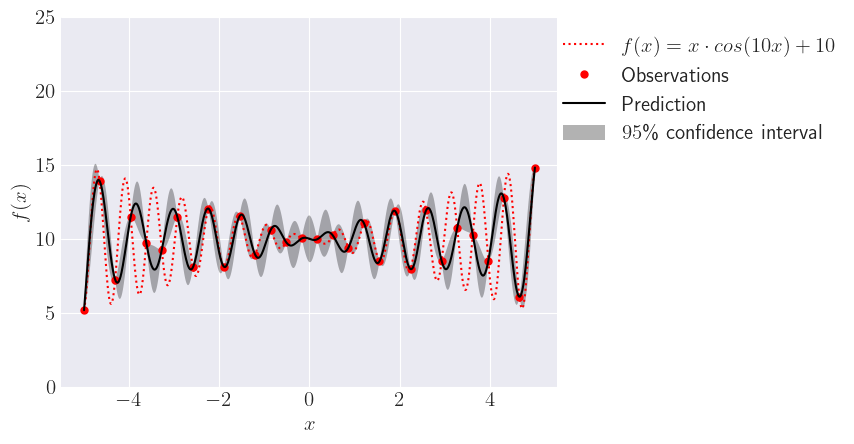

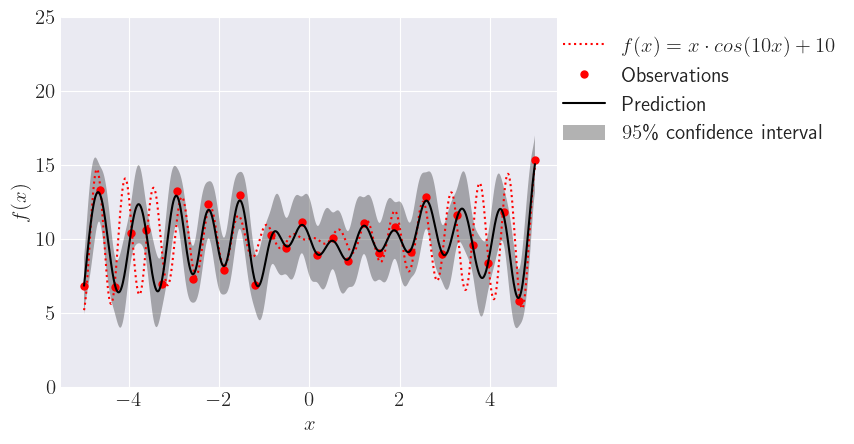

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from matplotlib import pyplot as plt

def f(X:np.ndarray):
    x = X.copy()
    return x * np.cos(10*x) + 10

def plot_results_2d(X_obs, y_obs, gp):
    x = np.atleast_2d(np.linspace(-5, 5, 1000)).T
    y_pred, sigma = gp.predict(x, return_std=True)
    plt.figure()
    plt.plot(x, f(x), 'r:', label='$f(x) = x \cdot cos(10x) + 10$')
    plt.plot(X_obs, y_obs, 'r.', markersize=10, label='Observations')
    plt.plot(x, y_pred, 'k-', label='Prediction')
    plt.fill(np.concatenate([x, x[::-1]]),
             np.concatenate([y_pred - 1.9600 * sigma,
                            (y_pred + 1.9600 * sigma)[::-1]]),
             alpha=.3, fc='k', label='$95$\% confidence interval')
    plt.xlabel('$x$')
    plt.ylabel('$f(x)$')
    plt.ylim(0, 25)
    plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1))
    plt.show()

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1)

xi = np.atleast_2d(np.linspace(-5, 5, 30)).T
fi = f(xi).ravel()
X = xi.copy()
y = fi.copy()
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100)
gp.fit(X, y)
plot_results_2d(X,y,gp)

rng = np.random.RandomState(1)
noise_std = 1
yn = y + rng.normal(loc=0.0, scale=noise_std, size=y.shape)
# TODO: implement the extension
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100, alpha=noise_std**2)
gp.fit(X, yn)
plot_results_2d(X, yn, gp)


### Gaussian Process Regression together with Expected Improvement in Noisy Setting

#### Task 3
Implement visualization of the EIn and GP for the given noisy data and compare the result with the noise-free case.

[ 5.17516986 13.91374468  7.24983647 11.49025734  9.71577518  9.25923172
 11.49382048  8.07166583 12.04415455  8.11618548 11.52358772  8.93935074
 10.59807597  9.77036017 10.02633472  9.97366528 10.22963983  9.40192403
 11.06064926  8.47641228 11.88381452  7.95584545 11.92833417  8.50617952
 10.74076828 10.28422482  8.50974266 12.75016353  6.08625532 14.82483014]
14.824830142460566


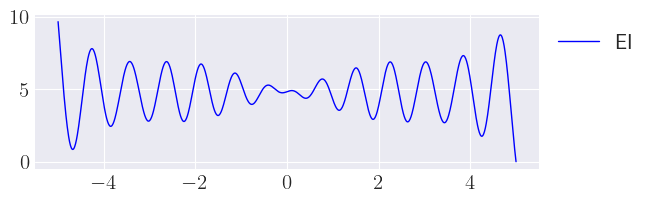

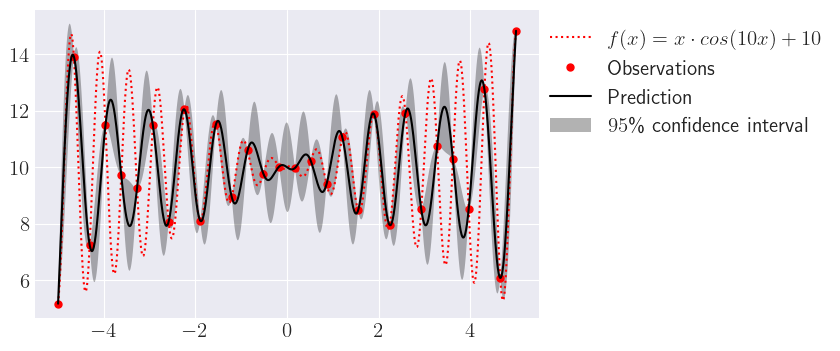

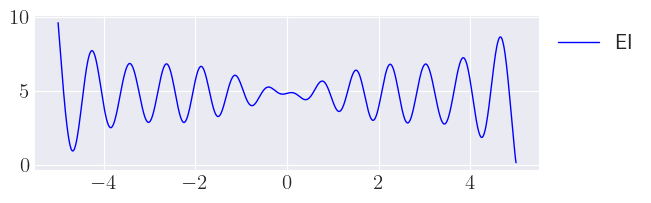

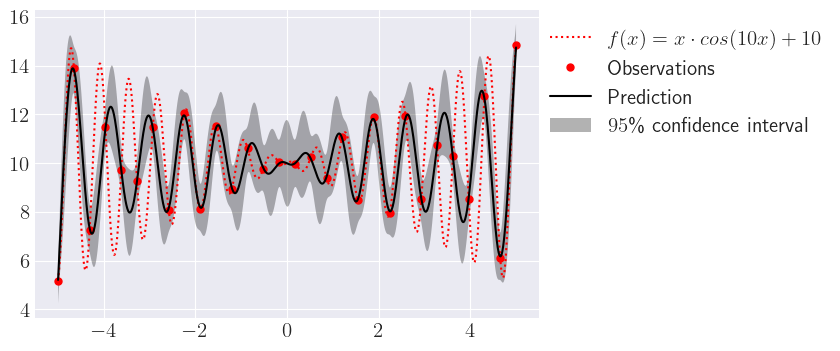

In [92]:
from sklearn.gaussian_process.kernels import Matern


def plot_prediction(train_x, train_y, gpr:GaussianProcessRegressor):
    m = []
    lb = []
    ub = []
    train_x = train_x.reshape((-1,1))
    train_y = train_y.reshape((-1,1))
    gpr.fit(train_x,train_y)
    x = np.linspace(-5, 5, 1000)
    for test_x in x:
        pred_mean, pred_std = gpr.predict(np.array([test_x]).reshape(-1,1),return_std=True)
        m.append(pred_mean)    
        if pred_std<0:
            print('Posterior standard deviation is negative ({:e}) at x={}, rounding up to 0'.format(pred_std, test_x))
            pred_std = 0
        s = pred_std.copy() 
        lb.append(pred_mean-1.96*s)
        ub.append(pred_mean+1.96*s)
    m = np.array(m).ravel()
    lb = np.array(lb).ravel()
    ub = np.array(ub).ravel()
    _, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(x, f(x), 'r:', label='$f(x) = x \cdot cos(10x) + 10$')
    ax.plot(train_x,train_y,'r.', markersize=10,label='Observations')
    ax.plot(x,m.ravel(),'k-',label='Prediction')    
    ax.fill_between(x,lb,ub,alpha=.3, fc='k', label='$95$\% confidence interval')
    ax.legend(bbox_to_anchor=(1.6, 1))


def plot_acq(train_x:np.ndarray,
            train_y:np.ndarray,
            GPR:GaussianProcessRegressor,
            f_star:float, 
            acq_fun=EI,
            acq_fun_name:str = "EI"):
    
    if train_x.shape[0] == train_x.size:
        train_x = train_x.reshape((-1,1))
    if train_y.shape[0] == train_y.size:
        train_y = train_y.reshape((-1,1))
    f_star:np.ndarray = np.array([f_star]).reshape((-1,1))
    GPR.fit(train_x,train_y)
    acq_cum = []   
    x = np.linspace(-5, 5, 1000)
    for test_x in x:
        pred_mean, pred_std = GPR.predict(test_x.reshape((-1,1)), return_std=True)
        acq = acq_fun(pred_mean.ravel(),np.power(pred_std.ravel(),2),f_star.ravel())
        acq_cum.append(acq)
    fig, ax = plt.subplots(figsize=(6.5, 2))
    ax.plot(x,acq_cum,'b',linewidth=1, label=acq_fun_name)
    ax.legend(bbox_to_anchor=(1, 1))


train_x = X
train_y = y

f_star = max(train_y)
print(train_y)
print(f_star)

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100)

gp.fit(X=train_x.reshape((-1,1)), y=train_y.reshape((-1,1)))

plot_acq(train_x, train_y,GPR = gp, f_star=f_star)
plot_prediction(train_x, train_y, gpr= gp)

rng = np.random.RandomState(1)
noise_std = 0.5
yn = train_y + rng.normal(loc=0.0, scale=noise_std, size=y.shape)
# TODO: implement the extension
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=100, alpha=noise_std**2)
gp.fit(X=train_x.reshape((-1,1)), y=yn.reshape((-1,1)))
plot_acq(train_x, train_y,GPR = gp, f_star=f_star)
plot_prediction(train_x, train_y, gpr= gp)